## Laboratorio 3
### Mollinedo Siles Renzo Sebastian

Dirección del repositorio:https://github.com/SoKierkegaard/SIS_420_Mollinedo_Siles_Renzo_Sebastian

### Carga de Librerías y Dataset
Utilizaremos Pandas para el preprocesamiento, tratando los valores nulos que son comunes en este dataset.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

from google.colab import drive
drive.mount('/content/drive')

# Carga del dataset (Asegúrate de haber subido train.csv a tu Drive o entorno)
path = '/content/drive/MyDrive/Colab Notebooks/Datasets/train.csv'
df = pd.read_csv(path)

# Crea una característica que cuente cuántos nulos hay por fila
df['n_missing'] = df.isnull().sum(axis=1)

# Ahora sí, rellena los nulos para poder entrenar
df.fillna(df.mean(), inplace=True)

print(f"Dimensiones del dataset: {df.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dimensiones del dataset: (957919, 121)


### Preparación y División de Datos (80/20)



In [30]:
# 1. Mezclar los datos (Crucial)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# 2. Separar X e y
X = df.drop(['id', 'claim'], axis=1).values
y = df['claim'].values

# 3. División
m_total = len(y)
m_train = int(0.8 * m_total)

X_train, X_test = X[:m_train], X[m_train:]
y_train, y_test = y[:m_train], y[m_train:]

def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1 # Evitar división entre cero
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_train, mu, sigma = featureNormalize(X_train)
X_test = (X_test - mu) / sigma # Normalizar test con parámetros de train

# Añadir columna de unos para el bias (theta_0)
X_train = np.concatenate([np.ones((X_train.shape[0], 1)), X_train], axis=1)
X_test = np.concatenate([np.ones((X_test.shape[0], 1)), X_test], axis=1)

### Definición del Modelo de Regresión Logística

In [31]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def costFunction(theta, X, y):
    m = y.size
    h = sigmoid(X.dot(theta))
    epsilon = 1e-15 # Evitar log(0)
    J = (1 / m) * np.sum(-y * np.log(h + epsilon) - (1 - y) * np.log(1 - h + epsilon))
    grad = (1 / m) * (h - y).dot(X)
    return J, grad

### Entrenamiento con Optimización Avanzada y Gráfica de Costo

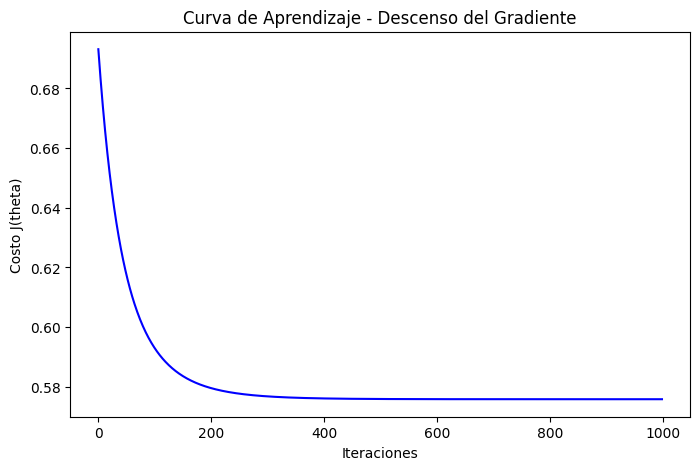

/tmp/ipykernel_310/26276775.py:22: OptimizeWarning: Unknown solver options: maxiter
  res = optimize.minimize(costFunction, initial_theta, (X_train, y_train),


In [32]:
# Historial de costo para la gráfica
def gradientDescent(X, y, theta, alpha, iters):
    cost_history = []
    for i in range(iters):
        cost, grad = costFunction(theta, X, y)
        theta = theta - alpha * grad
        cost_history.append(cost)
    return theta, cost_history

initial_theta = np.zeros(X_train.shape[1])
theta_manual, historial = gradientDescent(X_train, y_train, initial_theta, 0.05, 1000)

# Gráfica de Convergencia
plt.figure(figsize=(8, 5))
plt.plot(historial, color='blue')
plt.title('Curva de Aprendizaje - Descenso del Gradiente')
plt.xlabel('Iteraciones')
plt.ylabel('Costo J(theta)')
plt.show()

# Optimización final con TNC
res = optimize.minimize(costFunction, initial_theta, (X_train, y_train),
                        jac=True, method='TNC', options={'maxiter': 400})
theta_optimizado = res.x

### Validación y Predicciones
Evaluamos la efectividad del modelo con el 20% de datos reservados (test).

In [33]:
def predict(theta, X):
    return (sigmoid(X.dot(theta)) >= 0.5).astype(int)

# Precisión en datos de entrenamiento y prueba
p_train = np.mean(predict(theta_optimizado, X_train) == y_train) * 100
p_test = np.mean(predict(theta_optimizado, X_test) == y_test) * 100

print(f"Precisión en Entrenamiento: {p_train:.2f}%")
print(f"Precisión en Prueba (Validación): {p_test:.2f}%")

# Ejemplo de predicción individual
idx = 10
pred = predict(theta_optimizado, X_test[idx:idx+1])
print(f"\nEjemplo de Predicción: {pred[0]} | Valor Real: {y_test[idx]}")

Precisión en Entrenamiento: 73.77%
Precisión en Prueba (Validación): 73.81%

Ejemplo de Predicción: 0 | Valor Real: 1
